In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/ayesha73/powerplant/powerplant_data.csv')
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT -> Temparture
# V -> Vaccum
# AP -> Pressure
# RH -> Humidity
# PE ->Produced Energy
print(df.isnull().sum())
X=df.drop("PE",axis=1)
y=df["PE"]

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
X_train_tensor=torch.tensor(X_train_Scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_Scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [6]:
import torch.optim as optim
# Define ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
            # Output layer
            nn.Linear(6,1),  
        )
    def forward(self,x):
        return self.model(x)

model=ANN()
# Loss,Optimizer
crietirion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())
# Traning the Model
train_losses=[]
validation_losses=[]
best_valid_loss=float("inf")
epochs=50
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=crietirion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item() #loss is tensor value => float
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

# Validation
    
    model.eval()
    running_valid_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietirion(outputs,yb)
            running_valid_loss+=loss.item()
        epoch_valid_loss=running_valid_loss/len(test_loader)
        validation_losses.append(epoch_valid_loss)
        print(f"{epoch+1}/{epochs} => Training_Loss :{epoch_train_loss} Validation_loss :{epoch_valid_loss}" )
        if epoch_valid_loss <best_valid_loss:
            best_valid_loss=epoch_valid_loss
            torch.save(model.state_dict(), "best_model.pt")  

1/50 => Training_Loss :206331.00052083333 Validation_loss :204650.95130208333
2/50 => Training_Loss :198614.96477864584 Validation_loss :188136.46588541666
3/50 => Training_Loss :168243.61162109376 Validation_loss :143634.11080729167
4/50 => Training_Loss :118888.9724609375 Validation_loss :97059.8234375
5/50 => Training_Loss :82564.85185546875 Validation_loss :69588.254296875
6/50 => Training_Loss :58553.549825032555 Validation_loss :47420.13190104167
7/50 => Training_Loss :37521.237052408855 Validation_loss :27581.259440104168
8/50 => Training_Loss :19882.369030761718 Validation_loss :12732.313916015624
9/50 => Training_Loss :9045.001336669922 Validation_loss :6180.938094075521
10/50 => Training_Loss :5136.282719930013 Validation_loss :4129.436222330729
11/50 => Training_Loss :3780.5817927042644 Validation_loss :3290.792803955078
12/50 => Training_Loss :3105.0004419962565 Validation_loss :2758.7438537597654
13/50 => Training_Loss :2620.219490814209 Validation_loss :2361.942578125
14/

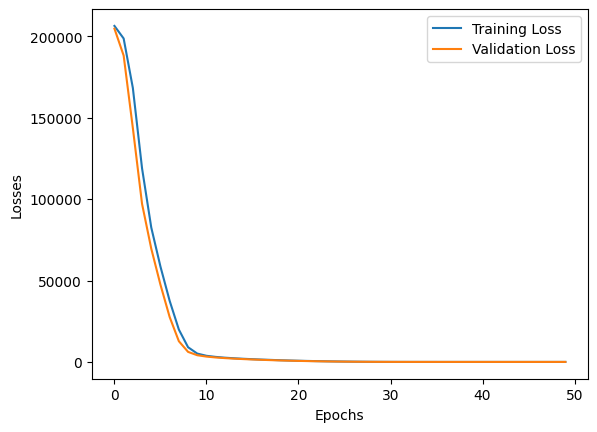

In [9]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_Loss": train_losses,
    "Validation_Loss": validation_losses
})

plt.plot(loss_df["Training_Loss"], label="Training Loss")
plt.plot(loss_df["Validation_Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

In [18]:
# Loading the Best Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
# Evaluation
from sklearn.metrics import r2_score
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)
    train_mse_loss=crietirion(train_preds,y_train_tensor)
    test_mse_loss=crietirion(test_preds,y_test_tensor)
    print("Training loss:",train_mse_loss.item())
    print("Testing loss:",test_mse_loss.item())
    print("R2_Score:",r2_score(y_test,test_preds))
    
    

Training loss: 21.40062141418457
Testing loss: 19.638757705688477
R2_Score: 0.9313676101979053


In [25]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted_Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual_Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted_Values,Actual_Values
0,435.193909,433.27
1,436.123779,438.16
2,460.912842,458.42
3,475.723083,480.82
4,434.973907,441.41
...,...,...
1909,450.899811,456.70
1910,431.106537,438.04
1911,467.754303,467.80
1912,430.431427,437.14
